In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_excel('practica_actividad_fisica.xlsx')

In [42]:
print("Primeras filas del dataset:")
display(df.head())

Primeras filas del dataset:


,person_id,age,gender,weekly_exercise_hours,daily_steps,water_intake_liters,sleep_hours,stress_level
0,1,32,Female,5.106652,5891.740130,5.500000,8.425652,5.0
1,2,48,Male,8.428179,6282.749435,1.725950,6.433732,2.0
2,3,36,Male,5.344177,10487.805126,2.192162,5.984617,2.0
3,4,19,Female,3.952726,5847.264410,2.583749,8.376822,1.0
4,5,30,Female,5.286090,7014.847512,1.886278,6.503400,3.0


In [43]:
print("\n===== INFORMACIÓN GENERAL =====")
df.info()

print("\n===== ESTADÍSTICAS DESCRIPTIVAS =====")
display(df.describe())

print("\n===== VALORES ÚNICOS POR COLUMNA =====")
display(df.nunique())

print("\n===== DISTRIBUCIÓN POR GÉNERO =====")
display(df['gender'].value_counts())



===== INFORMACIÓN GENERAL =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   person_id              200 non-null    int64  
 1   age                    200 non-null    int64  
 2   gender                 200 non-null    object 
 3   weekly_exercise_hours  200 non-null    float64
 4   daily_steps            200 non-null    float64
 5   water_intake_liters    200 non-null    float64
 6   sleep_hours            195 non-null    float64
 7   stress_level           191 non-null    float64
dtypes: float64(5), int64(2), object(1)
memory usage: 12.6+ KB

===== ESTADÍSTICAS DESCRIPTIVAS =====


,person_id,age,weekly_exercise_hours,daily_steps,water_intake_liters,sleep_hours,stress_level
count,200.000000,200.000000,200.000000,200.000000,200.000000,195.000000,191.000000
mean,100.500000,40.765000,5.111541,7258.033715,2.056943,7.043228,3.099476
std,57.879185,13.751556,2.004825,3310.700626,0.717076,1.526574,1.212023
min,1.000000,18.000000,0.000000,500.000000,0.000000,3.710684,1.000000
25%,50.750000,28.750000,3.761347,5643.461554,1.670666,5.938285,2.000000
50%,100.500000,42.500000,5.178963,6984.850065,1.982861,7.031148,3.000000
75%,150.250000,52.000000,6.351035,8471.828476,2.342013,8.166954,4.000000
max,200.000000,64.000000,10.018529,30000.000000,6.500000,11.191101,5.000000



===== VALORES ÚNICOS POR COLUMNA =====


person_id                200
age                       47
gender                     3
weekly_exercise_hours    199
daily_steps              200
water_intake_liters      200
sleep_hours              195
stress_level               5
dtype: int64


===== DISTRIBUCIÓN POR GÉNERO =====


gender
Female    98
Male      88
Other     14
Name: count, dtype: int64

In [44]:
print("Valores faltantes por columna antes del tratamiento:")
print(df.isnull().sum())

# Rellenar valores faltantes numéricos con la mediana y categóricos con la moda
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\n✅ Valores faltantes tratados.")
print(df.isnull().sum())

Valores faltantes por columna antes del tratamiento:
person_id                0
age                      0
gender                   0
weekly_exercise_hours    0
daily_steps              0
water_intake_liters      0
sleep_hours              5
stress_level             9
dtype: int64

✅ Valores faltantes tratados.
person_id                0
age                      0
gender                   0
weekly_exercise_hours    0
daily_steps              0
water_intake_liters      0
sleep_hours              0
stress_level             0
dtype: int64


In [45]:
# Guardar copia antes de eliminar outliers
df_before = df.copy()

# Columnas numéricas relevantes
num_cols = ["age", "weekly_exercise_hours", "daily_steps", "water_intake_liters", "sleep_hours"]

# Calcular IQR (rango intercuartílico)
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Número de outliers detectados
outliers = ((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).sum()
print("\nNúmero de outliers detectados por columna:")
print(outliers)

# Eliminar outliers
for col in num_cols:
    df = df[(df[col] >= lower_bound[col]) & (df[col] <= upper_bound[col])]

print("\nTamaño del dataset antes de eliminar outliers:", df_before.shape)
print("Tamaño del dataset después de eliminar outliers:", df.shape)


Número de outliers detectados por columna:
age                      0
weekly_exercise_hours    0
daily_steps              5
water_intake_liters      5
sleep_hours              0
dtype: int64

Tamaño del dataset antes de eliminar outliers: (200, 8)
Tamaño del dataset después de eliminar outliers: (190, 8)


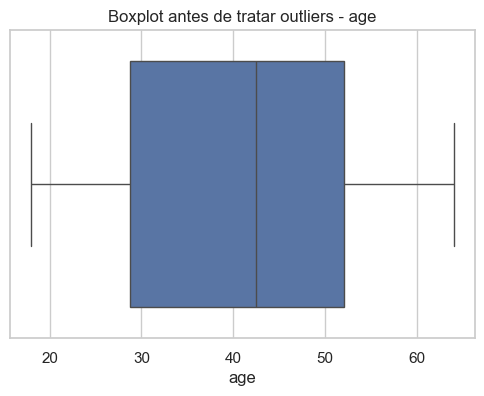

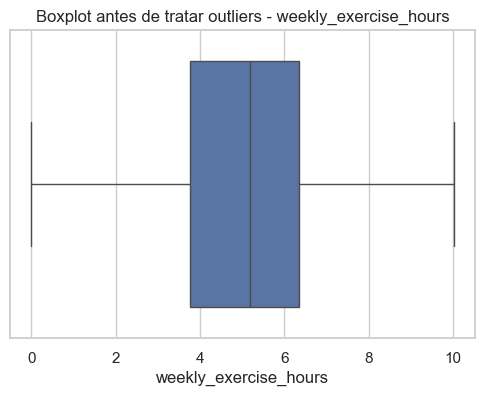

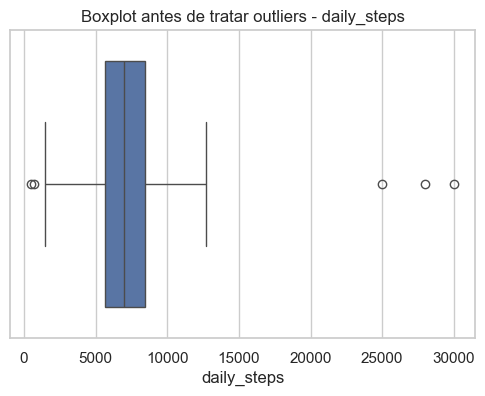

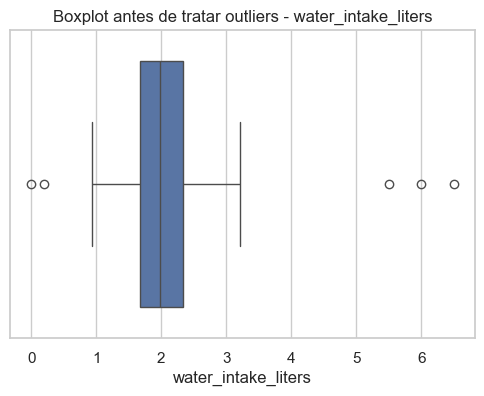

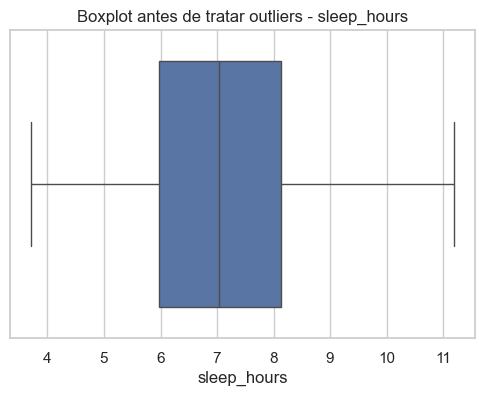

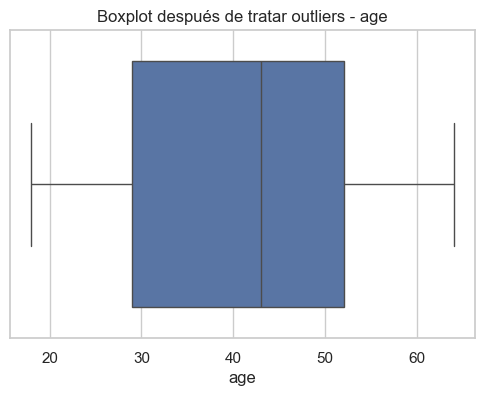

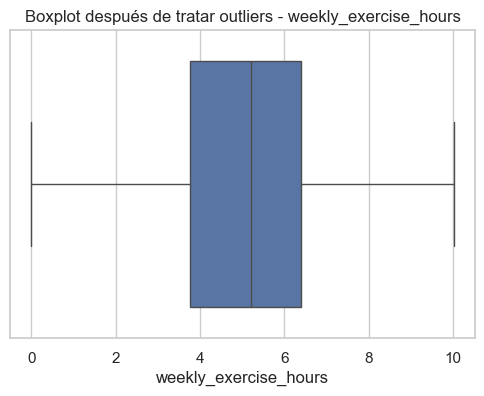

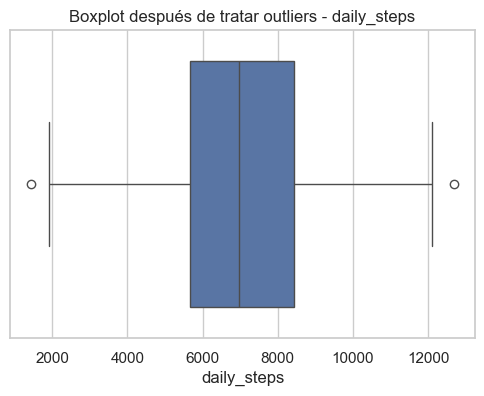

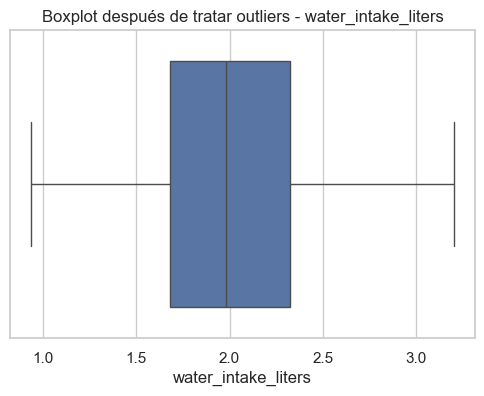

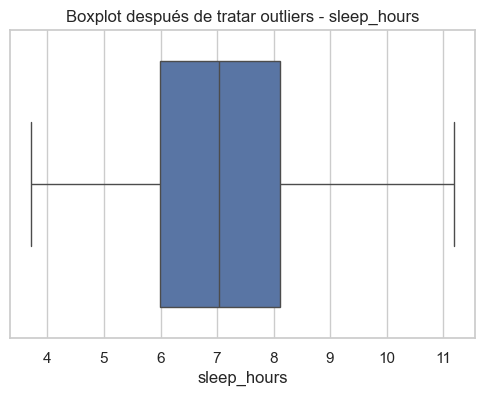

In [46]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_before[col])
    plt.title(f"Boxplot antes de tratar outliers - {col}")
    plt.show()

# Boxplots después
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot después de tratar outliers - {col}")
    plt.show()

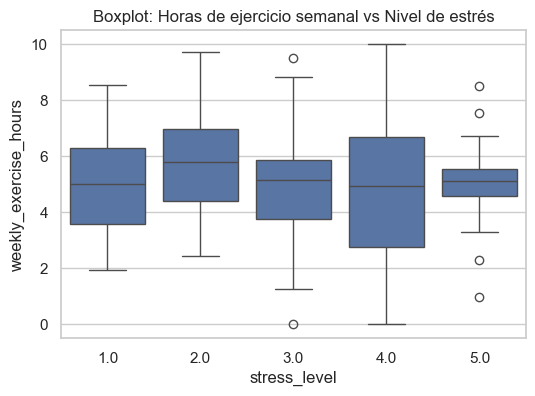

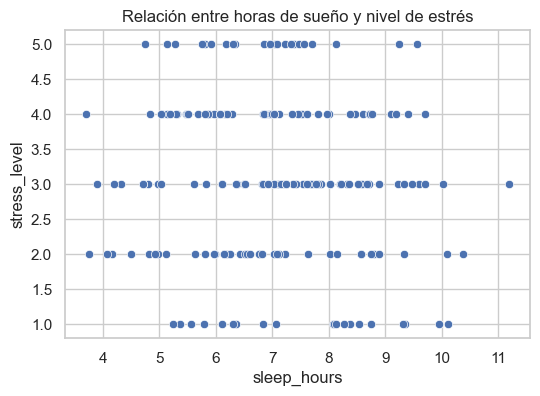

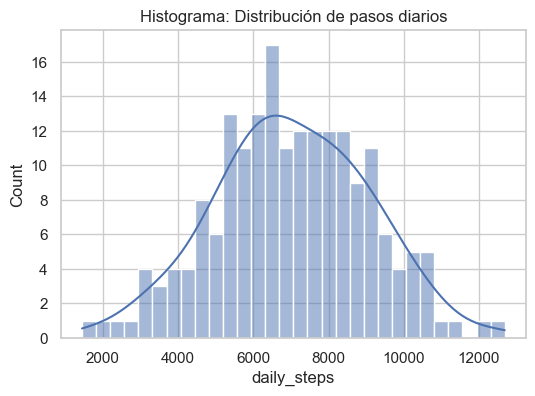

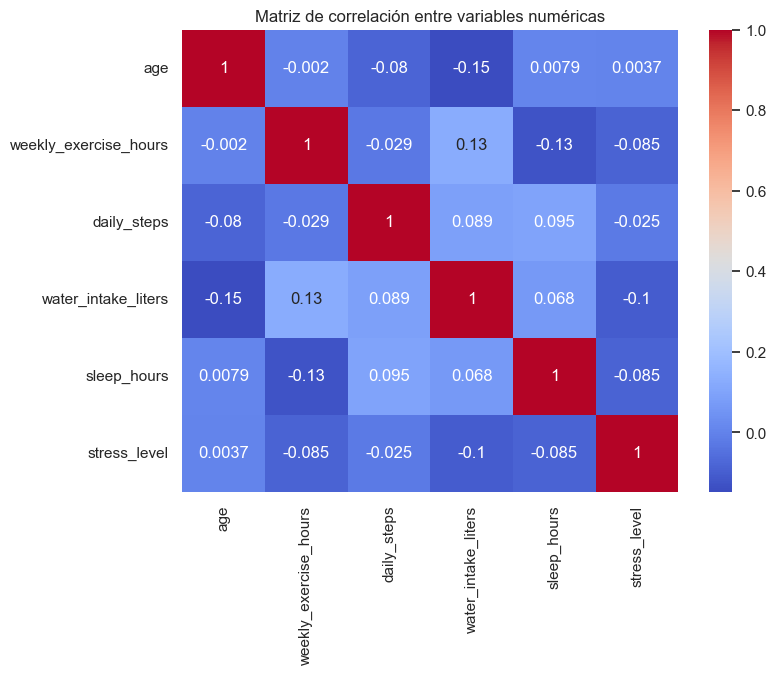

In [47]:
# Boxplot: stress_level vs weekly_exercise_hours
plt.figure(figsize=(6,4))
sns.boxplot(x="stress_level", y="weekly_exercise_hours", data=df)
plt.title("Boxplot: Horas de ejercicio semanal vs Nivel de estrés")
plt.show()

# Scatterplot: sleep_hours vs stress_level
plt.figure(figsize=(6,4))
sns.scatterplot(x="sleep_hours", y="stress_level", data=df)
plt.title("Relación entre horas de sueño y nivel de estrés")
plt.show()

# Histograma: daily_steps
plt.figure(figsize=(6,4))
sns.histplot(df["daily_steps"], bins=30, kde=True)
plt.title("Histograma: Distribución de pasos diarios")
plt.show()

# Matriz de correlación
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + ["stress_level"]].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

In [48]:
# =========================================================
# 7. CONCLUSIONES
# =========================================================

print("""
CONCLUSIONES:
1. Los valores faltantes fueron tratados mediante imputación con la mediana (numéricas) y moda (categóricas).
2. Se detectaron y eliminaron valores atípicos usando el método del IQR.
3. Los gráficos muestran una distribución más limpia y sin valores extremos luego del tratamiento.
4. Se observó una correlación negativa entre las horas de ejercicio, horas de sueño y el nivel de estrés.
5. Las personas con mayor ejercicio, más sueño y mayor consumo de agua tienden a tener menores niveles de estrés.
6. Promover estos hábitos podría contribuir a una mejor gestión del estrés.
""")



CONCLUSIONES:
1. Los valores faltantes fueron tratados mediante imputación con la mediana (numéricas) y moda (categóricas).
2. Se detectaron y eliminaron valores atípicos usando el método del IQR.
3. Los gráficos muestran una distribución más limpia y sin valores extremos luego del tratamiento.
4. Se observó una correlación negativa entre las horas de ejercicio, horas de sueño y el nivel de estrés.
5. Las personas con mayor ejercicio, más sueño y mayor consumo de agua tienden a tener menores niveles de estrés.
6. Promover estos hábitos podría contribuir a una mejor gestión del estrés.

